In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple, List

### Inicjalizacja Populacji

In [2]:
def initialize_population(pop_size: int, dim: int, bounds: Tuple[float, float], objective_func: Callable):
    population = np.random.uniform(bounds[0], bounds[1], (pop_size, dim))
    fitness = np.array([objective_func(individual) for individual in population])

    best_idx = np.argmin(fitness)
    best_solution = population[best_idx].copy()
    best_fitness = fitness[best_idx]

    return population, fitness, best_solution, best_fitness

### Selekcja Turniejowa

In [3]:
def tournament_selection(population: np.ndarray, fitness: np.ndarray, tournament_size: int = 3) -> np.ndarray:
    pop_size = population.shape[0]
    tournament_indices = np.random.choice(pop_size, tournament_size, replace=False)
    tournament_fitness = fitness[tournament_indices]
    winner_idx = tournament_indices[np.argmin(tournament_fitness)]
    return population[winner_idx].copy()

### Krzyżowanie Arytmetyczne

In [4]:
def arithmetic_crossover(parent1: np.ndarray, parent2: np.ndarray, alpha: float = 0.5) -> Tuple[np.ndarray, np.ndarray]:
    offspring1 = alpha * parent1 + (1 - alpha) * parent2
    offspring2 = (1 - alpha) * parent1 + alpha * parent2
    return offspring1, offspring2

### Krzyżowanie Jednopunktowe

In [5]:
def single_point_crossover(parent1: np.ndarray, parent2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    dim = len(parent1)
    point = np.random.randint(1, dim)

    offspring1 = np.concatenate([parent1[:point], parent2[point:]])
    offspring2 = np.concatenate([parent2[:point], parent1[point:]])

    return offspring1, offspring2

### Mutacja Gaussowska

In [6]:
def gaussian_mutation(individual: np.ndarray, bounds: Tuple[float, float],
                      mutation_rate: float = 0.1, mutation_scale: float = 0.1) -> np.ndarray:
    mutated = individual.copy()
    dim = len(individual)

    for i in range(dim):
        if np.random.random() < mutation_rate:
            noise = np.random.normal(0, mutation_scale * (bounds[1] - bounds[0]))
            mutated[i] = mutated[i] + noise
            mutated[i] = np.clip(mutated[i], bounds[0], bounds[1])

    return mutated

### Mutacja Uniform

In [7]:
def uniform_mutation(individual: np.ndarray, bounds: Tuple[float, float],
                     mutation_rate: float = 0.1) -> np.ndarray:
    mutated = individual.copy()
    dim = len(individual)

    for i in range(dim):
        if np.random.random() < mutation_rate:
            mutated[i] = np.random.uniform(bounds[0], bounds[1])

    return mutated

### Selekcja Elitarna

In [8]:
def elitism(population: np.ndarray, fitness: np.ndarray, n_elite: int) -> Tuple[np.ndarray, np.ndarray]:
    elite_indices = np.argsort(fitness)[:n_elite]
    elite_population = population[elite_indices].copy()
    elite_fitness = fitness[elite_indices].copy()
    return elite_population, elite_fitness

# Główna Pętla Algorytmu

In [9]:
def genetic_algorithm(pop_size: int, dim: int, bounds: Tuple[float, float],
                      max_generations: int, objective_func: Callable,
                      crossover_rate: float = 0.8,
                      mutation_rate: float = 0.1,
                      mutation_scale: float = 0.1,
                      elitism_rate: float = 0.1,
                      tournament_size: int = 3,
                      crossover_type: str = 'arithmetic',
                      mutation_type: str = 'gaussian'):
    # Inicjalizacja
    population, fitness, best_solution, best_fitness = initialize_population(
        pop_size, dim, bounds, objective_func
    )
    convergence_curve = [best_fitness]

    n_elite = max(1, int(pop_size * elitism_rate))

    # Wybór typu krzyżowania
    if crossover_type == 'arithmetic':
        crossover_func = arithmetic_crossover
    else:
        crossover_func = single_point_crossover

    # Wybór typu mutacji
    if mutation_type == 'gaussian':
        mutation_func = lambda ind: gaussian_mutation(ind, bounds, mutation_rate, mutation_scale)
    else:
        mutation_func = lambda ind: uniform_mutation(ind, bounds, mutation_rate)

    # Główna pętla
    for generation in range(max_generations):
        # Elityzm - zachowaj najlepsze osobniki
        elite_population, elite_fitness = elitism(population, fitness, n_elite)

        # Tworzenie nowej populacji
        new_population = []

        while len(new_population) < pop_size - n_elite:
            # Selekcja rodziców
            parent1 = tournament_selection(population, fitness, tournament_size)
            parent2 = tournament_selection(population, fitness, tournament_size)

            # Krzyżowanie
            if np.random.random() < crossover_rate:
                offspring1, offspring2 = crossover_func(parent1, parent2)
            else:
                offspring1, offspring2 = parent1.copy(), parent2.copy()

            # Mutacja
            offspring1 = mutation_func(offspring1)
            offspring2 = mutation_func(offspring2)

            new_population.append(offspring1)
            if len(new_population) < pop_size - n_elite:
                new_population.append(offspring2)

        # Połączenie elity z nową populacją
        new_population = np.array(new_population)
        population = np.vstack([elite_population, new_population])

        # Obliczenie fitness
        fitness = np.array([objective_func(individual) for individual in population])

        # Aktualizacja najlepszego rozwiązania
        current_best_idx = np.argmin(fitness)
        if fitness[current_best_idx] < best_fitness:
            best_solution = population[current_best_idx].copy()
            best_fitness = fitness[current_best_idx]

        convergence_curve.append(best_fitness)

    return best_solution, best_fitness, convergence_curve

### Wizualizacja

In [10]:
def plot_convergence(convergence_curve):
    plt.figure(figsize=(10, 6))
    plt.plot(convergence_curve, 'r-', linewidth=2)
    plt.xlabel('Generacja')
    plt.ylabel('Najlepsza wartość funkcji celu')
    plt.title('Krzywa zbieżności algorytmu genetycznego')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.show()

# Funkcje Testowe

#### Funkcja Stepowa

In [11]:
def step_function(x: np.ndarray) -> float:
    return np.sum(np.floor(x + 0.5) ** 2)

#### Funkcja Sferyczna

In [12]:
def sphere_function(x: np.ndarray) -> float:
    return np.sum(x ** 2)

#### Funckja Rastrigina

In [13]:
def rastrigin_function(x: np.ndarray, A: float = 10) -> float:
    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

#### Funckcja Rosenbrocka

In [14]:
def rosenbrock_function(x: np.ndarray) -> float:
    return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

#### Funkcja Zakharova

In [15]:
def zakharov_function(x: np.ndarray) -> float:
    i = np.arange(1, len(x) + 1)
    term = (np.sum(0.5 * i * x))
    return np.sum(x**2) + term**2 + term**4

#### Funkcja Griewank

In [16]:
def griewank_function(x: np.ndarray) -> float:
    i = np.arange(1, len(x) + 1)
    return 1 + (np.sum(x**2) / 4000.0) - (np.prod(np.cos(x / np.sqrt(i))))

# Wywołanie

Najlepsze rozwiązanie: [-0.00203657 -0.00174658  0.00136685 -0.0072989   0.00734473]
Wartość funkcji: 0.00011628545796108072


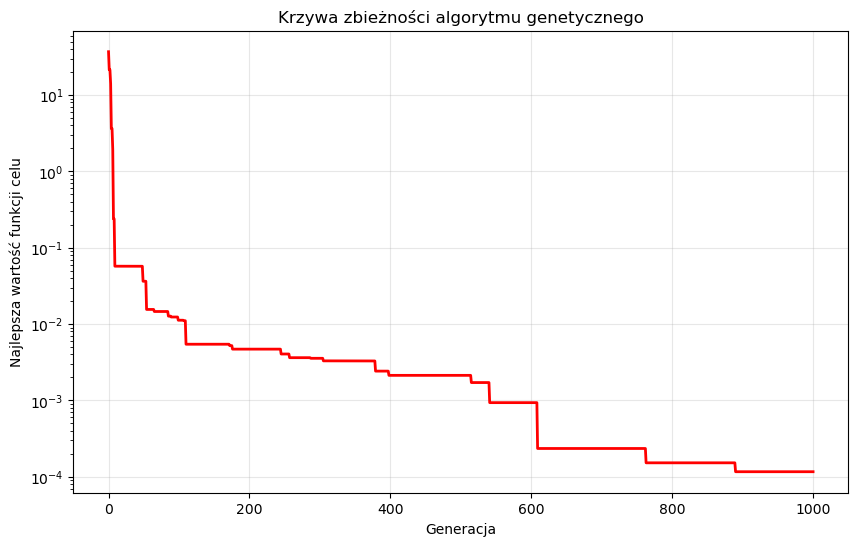

In [17]:
best_solution, best_value, convergence = genetic_algorithm(
    dim = 5,
    pop_size = 50,
    objective_func = sphere_function,
    bounds = [-10,10],
    max_generations = 1000,

    crossover_type = arithmetic_crossover,
    mutation_type = gaussian_mutation
)

print("Najlepsze rozwiązanie:", best_solution)
print("Wartość funkcji:", best_value)
plot_convergence(convergence)

# Obliczenie najlepzych wyników

In [18]:
def evaluate_ga_runs(n_runs,
                      pop_size: int, dim: int, bounds: Tuple[float, float],
                      max_generations: int, objective_func: Callable,
                      crossover_rate: float = 0.8,
                      mutation_rate: float = 0.1,
                      mutation_scale: float = 0.1,
                      elitism_rate: float = 0.1,
                      tournament_size: int = 3,
                      crossover_type: str = 'arithmetic',
                      mutation_type: str = 'gaussian'):
    all_solutions = []
    all_fitness = []

    for _ in range(n_runs):
        best_solution, best_value, convergence_curve = genetic_algorithm(
            pop_size, dim, bounds, max_generations, objective_func, crossover_rate, mutation_rate, mutation_scale, elitism_rate, tournament_size, crossover_type, mutation_type
        )
        all_solutions.append(best_solution)
        all_fitness.append(best_value)

    all_solutions = np.array(all_solutions)
    all_fitness = np.array(all_fitness)

    std_parameters = np.std(all_solutions, axis=0)
    std_fitness = np.std(all_fitness)

    best_idx = np.argmin(all_fitness)
    global_best_solution = all_solutions[best_idx]
    global_best_value = all_fitness[best_idx]

    return std_parameters, std_fitness, global_best_solution, global_best_value, convergence_curve

Najlepsze rozwiązanie: [-1.7204e-01, -6.0667e-03, 1.7820e-01, 9.6818e-03, -3.0000e-01, -3.6963e-01, 3.9164e-01, -2.2417e-01, -9.2949e-02, 3.5057e-01]
Odchylenie standardowe parametrów: [1.7129e-01, 1.3082e-01, 1.1930e-01, 2.8752e-01, 2.3256e-01, 2.6893e-01, 3.5378e-01, 4.8223e-01, 4.3949e-01, 7.1484e-01]
Wartość funkcji: 6.4454e-01
Odchylenie standardowe wartości funkcji: 1.3744e+00


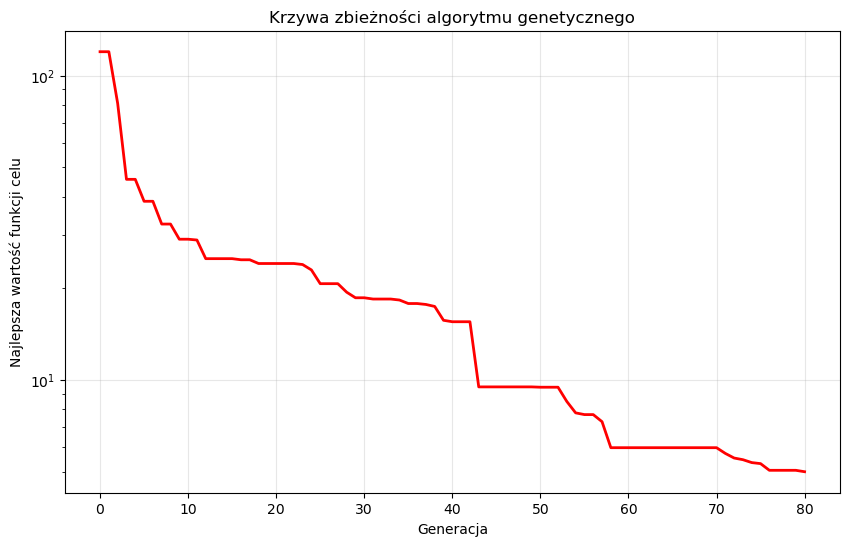

In [19]:
std_params, std_fit, best_solution, best_value, convergence = evaluate_ga_runs(
        n_runs=10,
        pop_size=50,
        dim=10,
        bounds=(-5, 10),
        max_generations=80,
        objective_func=zakharov_function,
        crossover_rate=0.8,
        mutation_rate=0.1,
        mutation_scale=0.1,
        elitism_rate=0.1,
        tournament_size=3,
        crossover_type='arithmetic',
        mutation_type='gaussian'
    )

print("Najlepsze rozwiązanie:", "[" + ", ".join(f"{x:.4e}" for x in best_solution) + "]")
print("Odchylenie standardowe parametrów:", "[" + ", ".join(f"{x:.4e}" for x in std_params) + "]")
print("Wartość funkcji:", f"{best_value:.4e}")
print("Odchylenie standardowe wartości funkcji:", f"{std_fit:.4e}")
plot_convergence(convergence)

## Główna pętla algorytmu z zapisywaniem pozycji agentów

In [20]:
def genetic_algorithm_position(pop_size: int, dim: int, bounds: Tuple[float, float],
                      max_generations: int, objective_func: Callable,
                      crossover_rate: float = 0.8,
                      mutation_rate: float = 0.1,
                      mutation_scale: float = 0.1,
                      elitism_rate: float = 0.1,
                      tournament_size: int = 3,
                      crossover_type: str = 'arithmetic',
                      mutation_type: str = 'gaussian',
                      save_every: int = 1):
    """
    Genetic Algorithm z logowaniem pozycji populacji (dla dim=2).
    """

    # Inicjalizacja
    population, fitness, best_solution, best_fitness = initialize_population(
        pop_size, dim, bounds, objective_func
    )
    convergence_curve = [best_fitness]

    # Log pozycji agentów
    positions_log = []
    if dim == 2:
        positions_log.append(population.copy())

    n_elite = max(1, int(pop_size * elitism_rate))

    # Wybór typu krzyżowania
    if crossover_type == 'arithmetic':
        crossover_func = arithmetic_crossover
    else:
        crossover_func = single_point_crossover

    # Wybór typu mutacji
    if mutation_type == 'gaussian':
        mutation_func = lambda ind: gaussian_mutation(ind, bounds, mutation_rate, mutation_scale)
    else:
        mutation_func = lambda ind: uniform_mutation(ind, bounds, mutation_rate)

    # Główna pętla
    for generation in range(max_generations):

        # Elityzm
        elite_population, elite_fitness = elitism(population, fitness, n_elite)

        # Tworzenie nowej populacji
        new_population = []

        while len(new_population) < pop_size - n_elite:
            parent1 = tournament_selection(population, fitness, tournament_size)
            parent2 = tournament_selection(population, fitness, tournament_size)

            # Krzyżowanie
            if np.random.random() < crossover_rate:
                offspring1, offspring2 = crossover_func(parent1, parent2)
            else:
                offspring1, offspring2 = parent1.copy(), parent2.copy()

            # Mutacja
            offspring1 = mutation_func(offspring1)
            offspring2 = mutation_func(offspring2)

            new_population.append(offspring1)
            if len(new_population) < pop_size - n_elite:
                new_population.append(offspring2)

        # Połączenie elity z nową populacją
        new_population = np.array(new_population)
        population = np.vstack([elite_population, new_population])

        # Obliczenie fitness
        fitness = np.array([objective_func(individual) for individual in population])

        # Aktualizacja najlepszego rozwiązania
        current_best_idx = np.argmin(fitness)
        if fitness[current_best_idx] < best_fitness:
            best_solution = population[current_best_idx].copy()
            best_fitness = fitness[current_best_idx]

        convergence_curve.append(best_fitness)

        # Logowanie pozycji co save_every generacji
        if dim == 2 and (generation + 1) % save_every == 0:
            positions_log.append(population.copy())

    return best_solution, best_fitness, convergence_curve, positions_log

### Wywołanie

In [26]:
best_solution, best_value, convergence, position_log = genetic_algorithm_position(
    dim = 2,
    pop_size = 20,
    objective_func = sphere_function,
    bounds = [-10,10],
    max_generations = 100,

    crossover_type = arithmetic_crossover,
    mutation_type = gaussian_mutation,

    save_every = 1
)

print("Najlepsze rozwiązanie:", best_solution)
print("Wartość funkcji:", best_value)
print(position_log)

Najlepsze rozwiązanie: [2.11069226e-05 1.71261542e-02]
Wartość funkcji: 0.0002933056048455167
[array([[ 7.12398133, -4.51213963],
       [-7.11800024, -7.30415939],
       [-8.29811107, -5.38069434],
       [ 0.10399822, -9.36313432],
       [-2.53147432,  8.06839213],
       [-3.9725953 ,  4.11084114],
       [-8.2678591 , -3.4284799 ],
       [ 9.40376852, -4.26844237],
       [-5.31158548, -6.41505976],
       [-9.1670505 ,  3.33121989],
       [ 9.22728652,  9.61344119],
       [-8.99191448, -7.55565281],
       [-7.93710121, -6.65733925],
       [ 9.90157647,  0.79514369],
       [ 4.02057949,  1.30340268],
       [-0.36958889, -8.45153661],
       [-9.53223511, -8.425844  ],
       [ 4.49940069, -0.87754753],
       [ 4.79875672,  0.01452159],
       [ 1.34749504,  2.83672812]]), array([[ 1.34749504,  2.83672812],
       [ 4.02057949,  1.30340268],
       [ 1.34749504,  4.11084114],
       [-3.9725953 ,  2.83672812],
       [-9.1670505 ,  0.01452159],
       [ 3.77659721,  3.3312

## Animacja ruchu agentów

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate_algorithm(positions_log, bounds, objective_func, interval=200):
    """
    Tworzy animację ruchu agentów algorytmu w 2D.
    
    positions_log: lista [T] elementów, każdy to macierz (n_agentów × 2)
    bounds: [(xmin, xmax), (ymin, ymax)]
    objective_func: funkcja celu f([x, y])
    interval: czas między klatkami w ms
    """

    # Przygotowanie siatki pod contour plot
    x = np.linspace(bounds[0][0], bounds[0][1], 200)
    y = np.linspace(bounds[1][0], bounds[1][1], 200)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = objective_func(np.array([X[i, j], Y[i, j]]))


    fig, ax = plt.subplots(figsize=(7, 7))

    # Tło: poziomice funkcji celu
    ax.contourf(X, Y, Z, levels=50, cmap='viridis')
    ax.set_xlim(bounds[0])
    ax.set_ylim(bounds[1])
    ax.set_title("Ruch agentów algorytmu")

    # Punkty agentów
    scatter = ax.scatter([], [], c='red', s=40)

    # Funkcja aktualizująca klatkę
    def update(frame):
        positions = positions_log[frame]
        scatter.set_offsets(positions)
        ax.set_title(f"Ruch agentów — iteracja {frame}")
        return scatter,

    anim = FuncAnimation(fig, update, frames=len(positions_log), interval=interval, blit=True)

    return anim

In [28]:
%matplotlib inline
from IPython.display import HTML

anim = animate_algorithm(position_log, bounds=[(-10,10), (-10,10)], objective_func=sphere_function)
HTML(anim.to_jshtml())